# Exercise: Gradient Computation for Multi-variable Functions

## Explanation

Compute gradients for a function with multiple inputs.

Given the function:

$$
f(x, y) = 3x^2y + 2y^2
$$

compute the partial derivatives:

$$
\frac{\partial f}{\partial x}
$$

and

$$
\frac{\partial f}{\partial y}
$$

at the input values:

$$
x = 1
$$

$$
y = 4
$$

---

## Expected Output

The computed gradient values:

$$
\frac{\partial f}{\partial x} = 6xy
$$

$$
\frac{\partial f}{\partial y} = 3x^2 + 4y
$$

evaluated at:

$$
x = 1, \quad y = 4
$$

So the numerical values are:

$$
\frac{\partial f}{\partial x}(1,4) = 24
$$

$$
\frac{\partial f}{\partial y}(1,4) = 19
$$

Therefore, the gradient is:

$$
\nabla f(1,4) = (24,\;19)
$$

In [ ]:
import torch
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(4.0, requires_grad=True)
f = 3*(x**2)*y + 2*y**2
f.backward()
print(f'df/dx @ (1,4): {x.grad}')
print(f'df/dy @ (1,4): {y.grad}')

df/dx @ (1,4): 24.0
df/dy @ (1,4): 19.0


# Exercise: PyTorch Automatic Differentiation Practice

## Explanation

Use PyTorch autograd to compute gradients for a multivariable function.

Given the function:

$$
f(x, y) = 5x^3y + 4y^2 - 2x
$$

compute the gradients:

$$
\frac{\partial f}{\partial x}
$$

and

$$
\frac{\partial f}{\partial y}
$$

at the input values:

$$
x = 2
$$

$$
y = 1
$$


## Expected Derivatives

The symbolic derivatives are:

$$
\frac{\partial f}{\partial x} = 15x^2y - 2
$$

$$
\frac{\partial f}{\partial y} = 5x^3 + 8y
$$

Evaluate them at:

$$
x = 2, \quad y = 1
$$


In [ ]:
import torch
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)
f = 5*(x**3)*y + 4*y**2 - 2*x
f.backward()
print(f'df/dx @ (2,1): {x.grad}')
print(f'df/dy @ (2,1): {y.grad}')

df/dx @ (2,1): 58.0
df/dy @ (2,1): 48.0


# Gradient Descent Visualization with PyTorch

## Objective

Use PyTorch to minimize the function:

$$
f(x) = x^4 - 3x^3 + 2
$$

Then visualize how gradient descent moves toward the minimum.

---

# Instructions

## 1. Initialize the Variable

Create a scalar PyTorch tensor `x` with:

- initial value: `0.5`
- gradient tracking enabled using `requires_grad=True`

---

## 2. Define the Function

Define the function:

$$
f(x) = x^4 - 3x^3 + 2
$$

---

## 3. Run Gradient Descent

Run gradient descent for approximately:

- 50–100 iterations

During each iteration:

1. Compute the current value of `f(x)`
2. Perform backpropagation to compute the derivative
3. Update `x` using:

$$
x \leftarrow x - \alpha \frac{df}{dx}
$$

4. Clear the stored gradients
5. Save:
   - the current `x`
   - the current `f(x)`

---

# Visualization

Create a graph showing:

- the curve of `f(x)`
- the sequence of gradient descent points
- arrows or connected lines showing the optimization path

Suggested plotting range:

$$
x \in [-1, 3]
$$

---

# Plot Labels

Add the following:

- **x-axis:** `x`
- **y-axis:** `f(x)`
- **title:** `Gradient Descent on f(x) = x^4 - 3x^3 + 2`

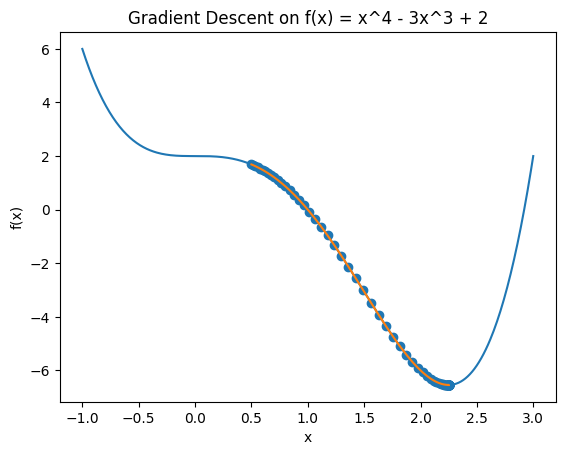

In [ ]:
import torch
import matplotlib.pyplot as plt

x = torch.tensor(0.5, requires_grad=True)
alpha = 0.01

x_records = []
f_records = []

for epoch in range(100):
  f =x**4 - 3*x**3 + 2
  x_records.append(x.item())
  f_records.append(f.item())
  f.backward()
  x_new = x - alpha * x.grad
  x = x_new.detach().requires_grad_(True)

x_plot = torch.linspace(-1, 3, 400)
f_plot = x_plot**4 - 3*x_plot**3 + 2

plt.plot(x_plot, f_plot)
plt.scatter(x_records, f_records)
plt.plot(x_records, f_records)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent on f(x) = x^4 - 3x^3 + 2")
plt.show()

# Gradient Descent in 2 Dimensions with PyTorch

## Objective

Use PyTorch gradient descent to minimize the function:

$$
f(x, y) = x^2 + y^2 + 3\sin(x)\cos(y)
$$

Then visualize the optimization trajectory on a contour plot.

---

# Instructions

## 1. Initialize the Variables

Create two PyTorch tensors:

- \(x = 2.0\)
- \(y = 2.0\)

Both should have gradient tracking enabled.

---

## 2. Define the Function

Define:

$$
f(x, y) = x^2 + y^2 + 3\sin(x)\cos(y)
$$

---

## 3. Run Gradient Descent

Choose a learning rate such as:

$$
\alpha = 0.05
$$

Run gradient descent for approximately:

- 100–300 iterations

During each iteration:

1. Compute the current function value
2. Perform backpropagation
3. Update both variables:

$$
x \leftarrow x - \alpha \frac{\partial f}{\partial x}
$$

$$
y \leftarrow y - \alpha \frac{\partial f}{\partial y}
$$

4. Reset the computation graph correctly for the next iteration
5. Store:
   - x positions
   - y positions
   - function values

---

# Visualization

## Create a Contour Plot

Visualize the function surface using contour lines.

Your graph should show:

- contour levels of the function
- the optimization trajectory
- the movement of gradient descent toward the minimum

# Plot Labels

Add:

- **x-axis:** `x`
- **y-axis:** `y`
- **title:** `2D Gradient Descent Visualization`

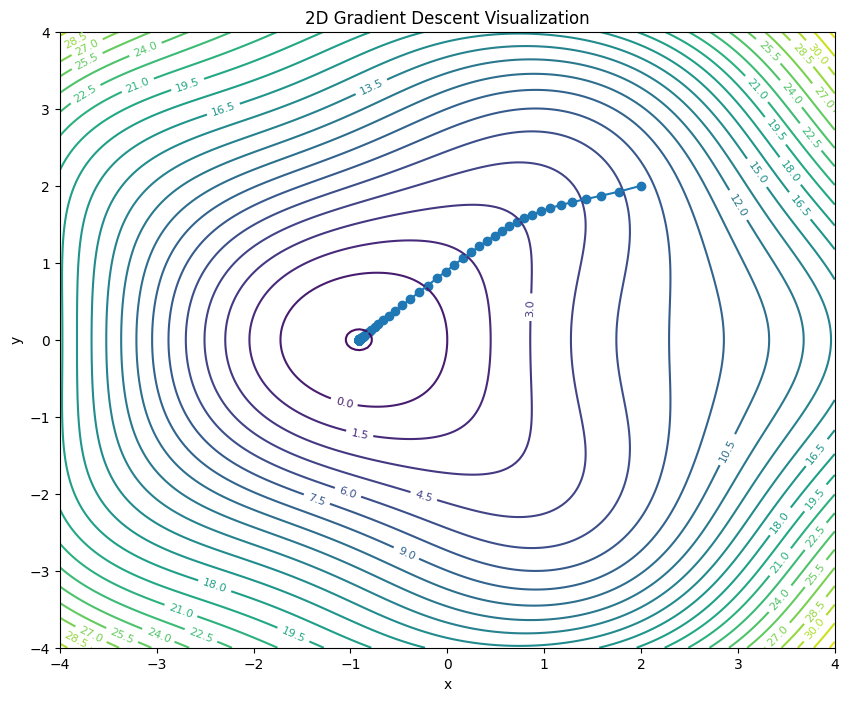

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
alpha = 0.05

x_records = []
y_records = []
f_records = []

for epoch in range(300):
  f = x**2 + y**2 + 3 * torch.sin(x) * torch.cos(y)
  x_records.append(x.item())
  y_records.append(y.item())
  f_records.append(f.item())
  f.backward()
  x_new = x - alpha * x.grad
  y_new = y - alpha * y.grad
  x = x_new.detach().requires_grad_(True)
  y = y_new.detach().requires_grad_(True)

x_plot = np.linspace(-4, 4, 200)
y_plot = np.linspace(-4, 4, 200)

X, Y = np.meshgrid(x_plot, y_plot)

Z = X**2 + Y**2 + 3 * np.sin(X) * np.cos(Y)

plt.figure(figsize=(10, 8))

contours = plt.contour(X, Y, Z, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(x_records, y_records)
plt.scatter(x_records, y_records)

plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Gradient Descent Visualization")

plt.show()